In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

In [ ]:
# configure

sns.set_theme(style='white')

COLOR_1 = "#439cfb"
COLOR_2 = "#f187fb"

# Auto-generate N shades from it
def make_palette(n):
    return [mcolors.to_hex(cmap(i)) for i in np.linspace(0, 1, n)]

# palette = sns.set_palette(make_palette(3))
# palette = sns.blend_palette([COLOR_1, COLOR_2], n_colors=3)
# palette = sns.light_palette("seagreen", n_colors=2))

# One line to build the gradient
cmap = mcolors.LinearSegmentedColormap.from_list("custom", [COLOR_1, COLOR_2])

HEATMAP_CMAP = cmap  # use directly in sns.heatmap(cmap=HEATMAP_CMAP)

In [ ]:
# load the data
df = sns.load_dataset('titanic')

In [ ]:
# inspect the data
print(df.shape)

(891, 15)


In [ ]:
print(df.sample(5))

     survived  pclass   sex   age  sibsp  parch     fare embarked  class  who  \
131         0       3  male  20.0      0      0   7.0500        S  Third  man   
202         0       3  male  34.0      0      0   6.4958        S  Third  man   
209         1       1  male  40.0      0      0  31.0000        C  First  man   
681         1       1  male  27.0      0      0  76.7292        C  First  man   
712         1       1  male  48.0      1      0  52.0000        S  First  man   

     adult_male deck  embark_town alive  alone  
131        True  NaN  Southampton    no   True  
202        True  NaN  Southampton    no   True  
209        True    A    Cherbourg   yes   True  
681        True    D    Cherbourg   yes   True  
712        True    C  Southampton   yes  False  


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None


In [ ]:
print(df.describe())

         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


In [ ]:
print(df.describe(include='all'))

          survived      pclass   sex         age       sibsp       parch  \
count   891.000000  891.000000   891  714.000000  891.000000  891.000000   
unique         NaN         NaN     2         NaN         NaN         NaN   
top            NaN         NaN  male         NaN         NaN         NaN   
freq           NaN         NaN   577         NaN         NaN         NaN   
mean      0.383838    2.308642   NaN   29.699118    0.523008    0.381594   
std       0.486592    0.836071   NaN   14.526497    1.102743    0.806057   
min       0.000000    1.000000   NaN    0.420000    0.000000    0.000000   
25%       0.000000    2.000000   NaN   20.125000    0.000000    0.000000   
50%       0.000000    3.000000   NaN   28.000000    0.000000    0.000000   
75%       1.000000    3.000000   NaN   38.000000    1.000000    0.000000   
max       1.000000    3.000000   NaN   80.000000    8.000000    6.000000   

              fare embarked  class  who adult_male deck  embark_town alive  \
count   8

In [ ]:
print(df.columns)

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')


In [ ]:
# Data Cleaning

# missing values
print(df.isnull().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [ ]:
# age is right skewed ,so fill with meidan
df['age'] = df['age'].fillna( df['age'].median() )

# too many missing values
df = df.drop('deck', axis=1)

# replace missing with most occured value
df['embark_town'] = df['embark_town'].fillna( df['embark_town'].mode()[0] )

# already have similar col as embark town
df = df.drop('embarked', axis=1)

In [ ]:
# duplicates
print(df.duplicated().sum())
df = df.drop_duplicates()

116


In [ ]:
# outliers
def outlier(col):
    q1 = np.percentile(col, 25)
    q3 = np.percentile(col, 75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

outlier(df['fare'])
outlier(df['age'])

print('fare bounds:', outlier(df['fare']))
print('age bounds: ', outlier(df['age']))

fare bounds: (np.float64(-31.171850000000003), np.float64(73.41975000000001))
age bounds:  (np.float64(-1.5), np.float64(58.5))


In [ ]:
# range check
print(df[df['age'] < 0])
print(df[df['fare'] < 0])

Empty DataFrame
Columns: [survived, pclass, sex, age, sibsp, parch, fare, class, who, adult_male, embark_town, alive, alone]
Index: []
Empty DataFrame
Columns: [survived, pclass, sex, age, sibsp, parch, fare, class, who, adult_male, embark_town, alive, alone]
Index: []


In [ ]:
# Feature Engineering
df['family_size'] = df['sibsp'] + df['parch'] +1
df['fare_pp'] = df['fare'] / df['family_size']

In [ ]:
# visualisation
print(df.sample(5))

     survived  pclass     sex   age  sibsp  parch     fare  class    who  \
6           0       1    male  54.0      0      0  51.8625  First    man   
96          0       1    male  71.0      0      0  34.6542  First    man   
433         0       3    male  17.0      0      0   7.1250  Third    man   
794         0       3    male  25.0      0      0   7.8958  Third    man   
799         0       3  female  30.0      1      1  24.1500  Third  woman   

     adult_male  embark_town alive  alone  family_size  fare_pp  
6          True  Southampton    no   True            1  51.8625  
96         True    Cherbourg    no   True            1  34.6542  
433        True  Southampton    no   True            1   7.1250  
794        True  Southampton    no   True            1   7.8958  
799       False  Southampton    no  False            3   8.0500  


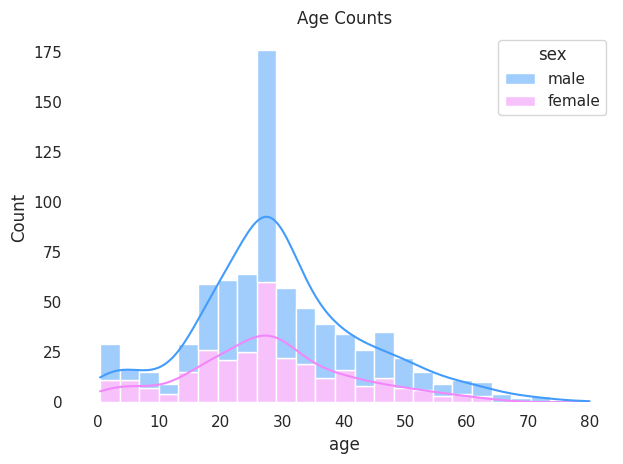

In [ ]:
sns.histplot(data=df,x='age',hue='sex', kde=True, palette = sns.blend_palette([COLOR_1, COLOR_2], n_colors=2),multiple='stack') # multiple = 'dodge'
sns.despine(left=True,bottom=True)
plt.title('Age Counts')
plt.tight_layout()
plt.show()

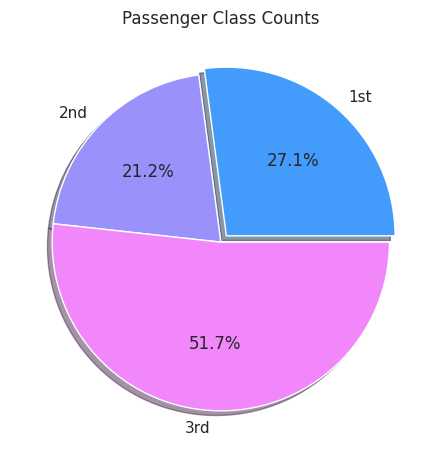

In [ ]:
class_count = df['pclass'].value_counts().sort_index()

plt.pie(class_count, labels=['1st','2nd','3rd'], explode=[0.05,0,0], shadow=1, autopct='%1.1f%%', colors=sns.blend_palette([COLOR_1, COLOR_2], n_colors=3))
plt.title('Passenger Class Counts')
plt.tight_layout()

plt.savefig('PassengerClassCounts.png')
plt.show()

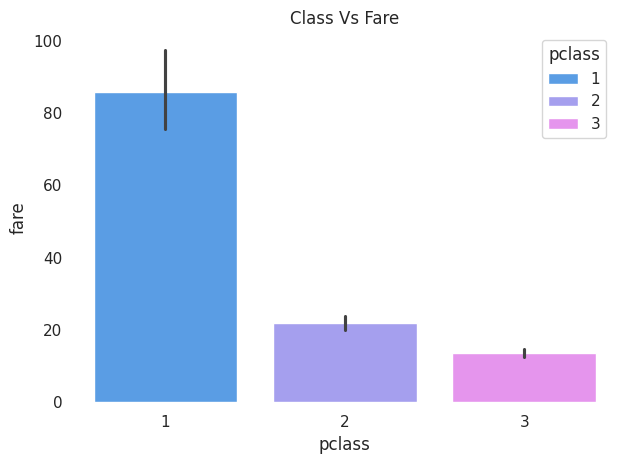

In [ ]:
sns.barplot(data=df,x='pclass',y='fare',hue='pclass', palette = sns.blend_palette([COLOR_1, COLOR_2], n_colors=3))
sns.despine(left=True,bottom=True)
plt.title('Class Vs Fare')
plt.tight_layout()
plt.show()

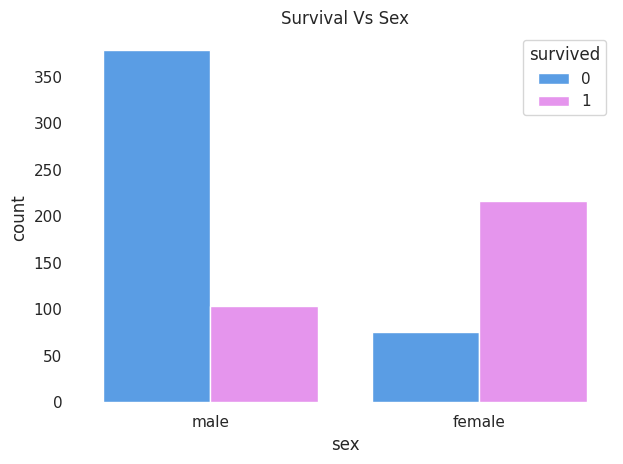

In [ ]:
sns.countplot(data=df,x='sex',hue='survived', palette = sns.blend_palette([COLOR_1, COLOR_2], n_colors=2))
sns.despine(left=True,bottom=True)
plt.title('Survival Vs Sex')
plt.tight_layout()
plt.savefig('survival_by_sex.png')
plt.show()

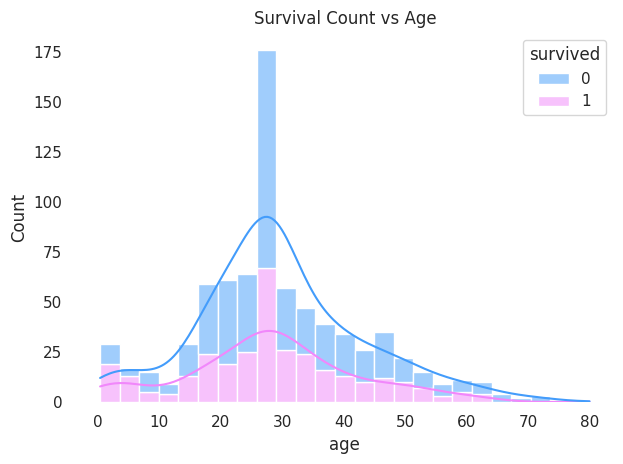

In [ ]:
sns.histplot(data=df,x='age',hue='survived',kde=True,multiple='stack', palette = sns.blend_palette([COLOR_1, COLOR_2], n_colors=2))
sns.despine(left=True,bottom=True)
plt.title('Survival Count vs Age')
plt.tight_layout()

plt.savefig('SurvivalByAge.png')
plt.show()

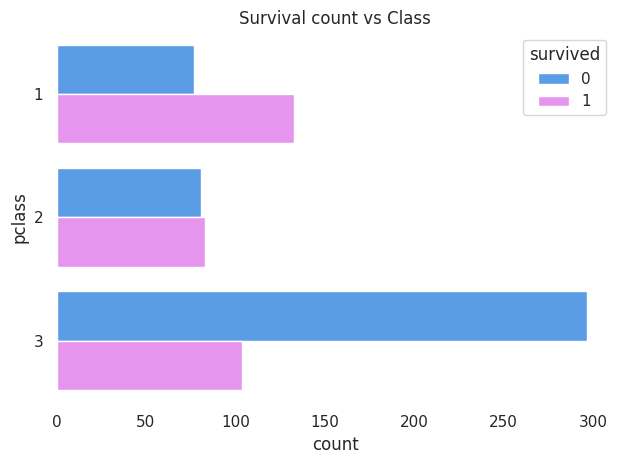

In [ ]:
sns.countplot(data=df,y='pclass',hue='survived', palette = sns.blend_palette([COLOR_1, COLOR_2], n_colors=2))
sns.despine(left=True,bottom=True)
plt.title('Survival count vs Class')
plt.tight_layout()
plt.show()

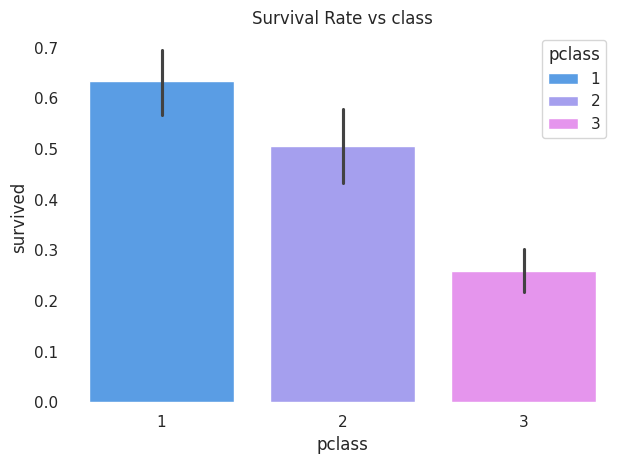

In [ ]:
sns.barplot(data=df,x='pclass',y='survived',hue='pclass', palette = sns.blend_palette([COLOR_1, COLOR_2], n_colors=3) )
sns.despine(left=True,bottom=True)
plt.title('Survival Rate vs class')
plt.tight_layout()
plt.show()

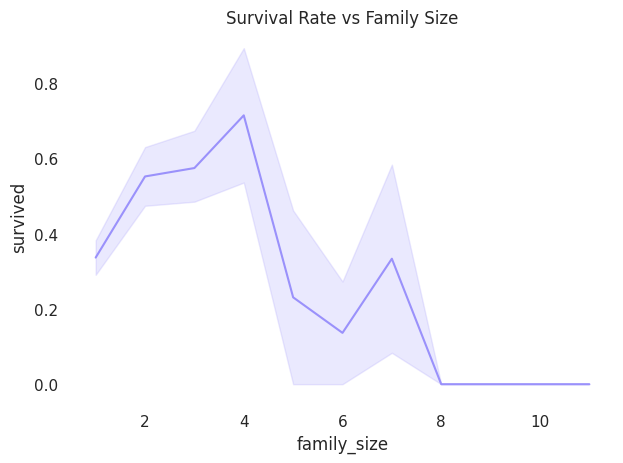

In [ ]:
sns.lineplot(df,x='family_size', y='survived', color = sns.blend_palette([COLOR_1, COLOR_2], n_colors=3)[1])
sns.despine(left=True,bottom=True)
plt.title('Survival Rate vs Family Size')
plt.tight_layout()

plt.savefig('survival_by_size.png')
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 14.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 16.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


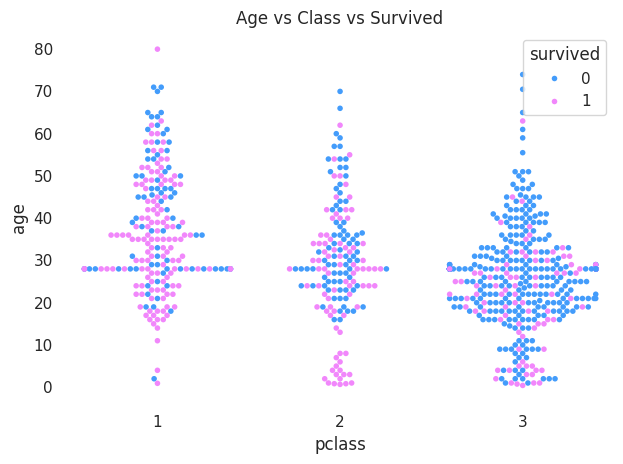

In [ ]:
sns.swarmplot(data=df, x='pclass', y='age', hue='survived', size=4, palette = sns.blend_palette([COLOR_1, COLOR_2], n_colors=2))
sns.despine(left=True,bottom=True)
plt.title('Age vs Class vs Survived')
plt.tight_layout()

plt.savefig('survival_by_age_class.png')
plt.show()

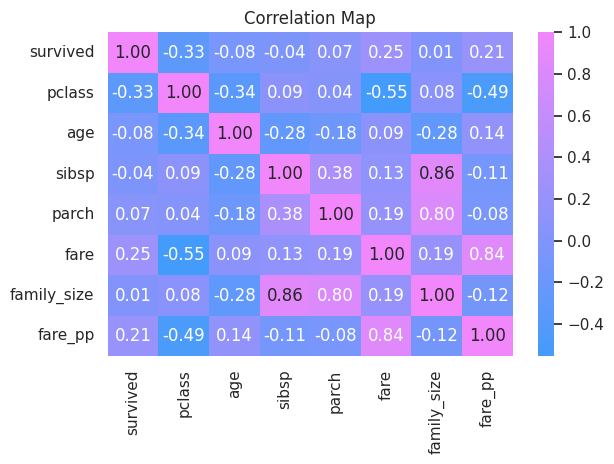

In [ ]:
num_cols = df.select_dtypes(include='number')
sns.heatmap(num_cols.corr(), annot=True, fmt='.2f', cmap=HEATMAP_CMAP)
plt.title('Correlation Map')
plt.tight_layout()
plt.savefig('Correlation_heatmap.png')
plt.show()


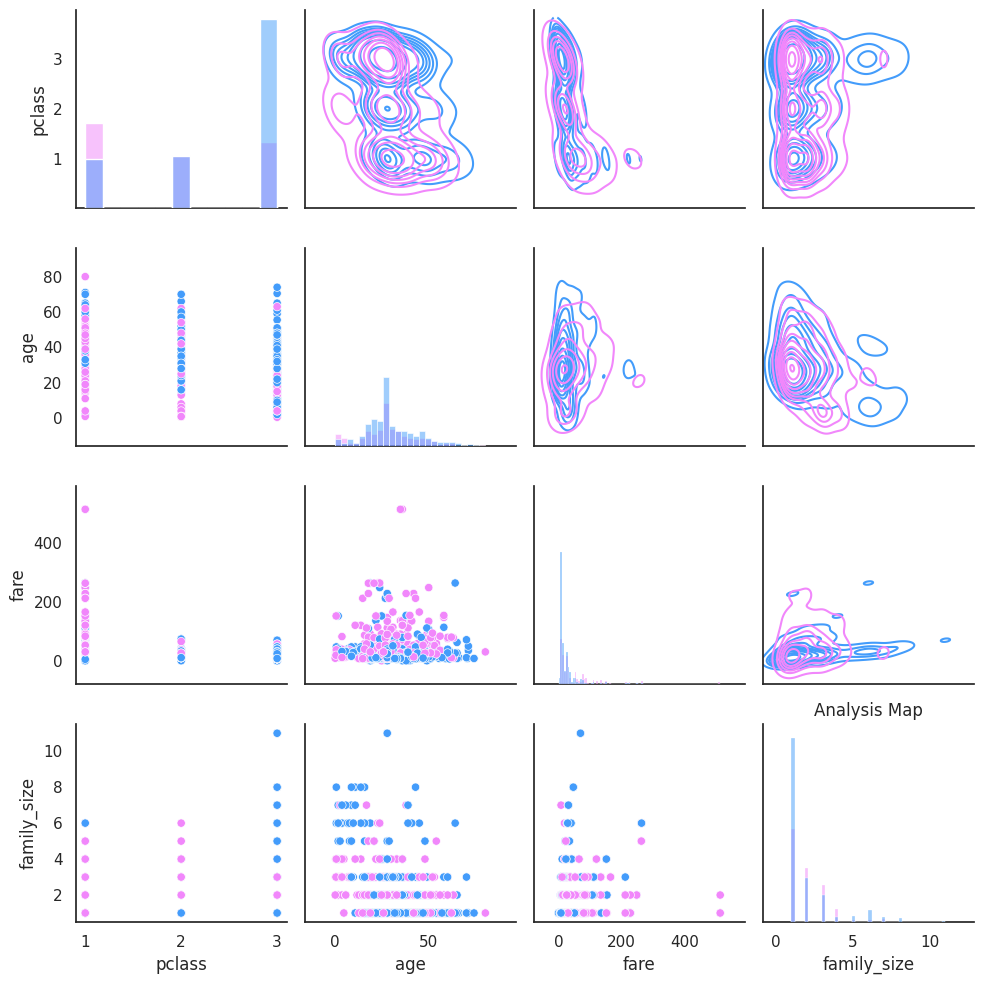

In [ ]:
cols = ['survived','pclass','age','fare','family_size']

graph = sns.PairGrid(df[cols], hue='survived', palette = sns.blend_palette([COLOR_1, COLOR_2], n_colors=2))
graph.map_upper(sns.kdeplot)
graph.map_diag(sns.histplot)
graph.map_lower(sns.scatterplot)

plt.title('Analysis Map')
plt.tight_layout()
plt.show()